**ROLL NO : 24BAD087**  
**NAME : POOVIKA M**

**EXP NO : 4**

**TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION**

**ENVIRONMENT SETUP & DEPENDENCIES**

In [2]:

!pip install -q transformers kagglehub torch torchvision matplotlib pillow

import os
import shutil
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline

# Configure hardware device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[STATUS] Running on device: {device}")

[STATUS] Running on device: cuda


**PART A — DATASET PREPARATION**

In [3]:
# 1. Download Kaggle Dataset (Flower Recognition: 5 classes)
print("[INFO] Downloading image dataset from Kaggle...")
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
dataset_dir = os.path.join(path, "flowers")

# 2. Define Image Preprocessing & Standard Transforms (224x224)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# 3. Split Dataset into Train (70%), Validation (15%), and Test (15%)
full_dataset = datasets.ImageFolder(root=dataset_dir, transform=data_transforms['train'])
classes = full_dataset.classes
num_classes = len(classes)

total_len = len(full_dataset)
train_len = int(0.70 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_data, val_data, test_data = random_split(full_dataset, [train_len, val_len, test_len])

# Assign validation/test transform to non-training splits
val_data.dataset.transform = data_transforms['val_test']
test_data.dataset.transform = data_transforms['val_test']

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"[INFO] Target Classes ({num_classes}): {classes}")
print(f"[INFO] Training Samples   : {len(train_data)}")
print(f"[INFO] Validation Samples : {len(val_data)}")
print(f"[INFO] Testing Samples    : {len(test_data)}")

[INFO] Downloading image dataset from Kaggle...


100%|██████████| 225M/225M [00:11<00:00, 21.1MB/s]

Extracting files...


[INFO] Target Classes (5): ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
[INFO] Training Samples   : 3021
[INFO] Validation Samples : 647
[INFO] Testing Samples    : 649


**PART B — IMPLEMENTING TRANSFER LEARNING**

In [4]:
# 1. Load Pre-trained ResNet-50 Model
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# 2. Freeze Feature Extraction Layers
for param in model.parameters():
    param.requires_grad = False

# 3. Replace Final Classification Layer
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

model = model.to(device)

# 4. Compile Model (Loss Function & Optimizer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("[INFO] Model compiled successfully with frozen base and custom classifier head.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


[INFO] Model compiled successfully with frozen base and custom classifier head.


**PART C — MODEL TRAINING AND PERFORMANCE EVALUATION**

--- Starting Transfer Learning Training Loop ---
Epoch [1/5] | Train Loss: 0.5697 | Train Acc: 81.46% | Val Loss: 0.3042 | Val Acc: 88.87%
Epoch [2/5] | Train Loss: 0.2477 | Train Acc: 91.49% | Val Loss: 0.2696 | Val Acc: 91.34%
Epoch [3/5] | Train Loss: 0.1803 | Train Acc: 93.91% | Val Loss: 0.2507 | Val Acc: 91.96%
Epoch [4/5] | Train Loss: 0.1285 | Train Acc: 95.76% | Val Loss: 0.2325 | Val Acc: 92.89%
Epoch [5/5] | Train Loss: 0.1097 | Train Acc: 96.46% | Val Loss: 0.2487 | Val Acc: 93.20%

Training Accuracy   : 96.46%
Validation Accuracy : 93.20%
Training Loss       : 0.1097
Validation Loss     : 0.2487
Test Accuracy       : 91.83%


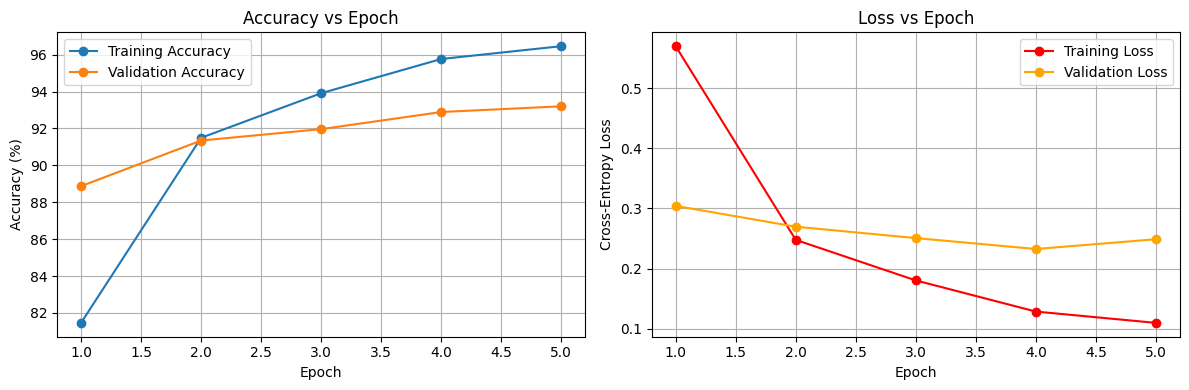

In [5]:
# 1. Train the Transfer Learning Model
epochs = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("--- Starting Transfer Learning Training Loop ---")
for epoch in range(epochs):
    # Training step
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation step
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc * 100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc * 100:.2f}%")

# 2. Evaluate on Unseen Test Set
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_correct += torch.sum(preds == labels.data).item()
        test_total += labels.size(0)

test_accuracy = (test_correct / test_total) * 100

print(f"\nTraining Accuracy   : {history['train_acc'][-1] * 100:.2f}%")
print(f"Validation Accuracy : {history['val_acc'][-1] * 100:.2f}%")
print(f"Training Loss       : {history['train_loss'][-1]:.4f}")
print(f"Validation Loss     : {history['val_loss'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.2f}%")

# 3. Visualize Accuracy vs Epoch & Loss vs Epoch
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), [acc * 100 for acc in history['train_acc']], marker='o', label='Training Accuracy')
plt.plot(range(1, epochs + 1), [acc * 100 for acc in history['val_acc']], marker='o', label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_loss'], marker='o', color='red', label='Training Loss')
plt.plot(range(1, epochs + 1), history['val_loss'], marker='o', color='orange', label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**PART D — USING HUGGING FACE PRE-TRAINED MODELS & COMPARISON**

--- Hugging Face Pre-trained Model Inference ---


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Ground Truth Class             : daisy
Transfer Learning (ResNet-50)  : daisy
Hugging Face (ViT) Prediction  : daisy (Score: 0.9992)


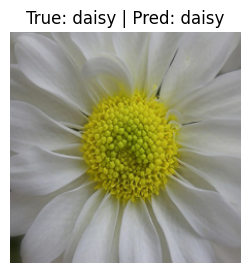

In [6]:
# 1. Load Pre-trained Vision Model from Hugging Face
print("--- Hugging Face Pre-trained Model Inference ---")
hf_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

# 2. Perform Classification on a Sample Test Image
sample_tensor, true_label_idx = test_data[0]

# Denormalize tensor to display as PIL Image
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
sample_pil = transforms.ToPILImage()(inv_normalize(sample_tensor).clamp(0, 1))

# Hugging Face inference
hf_preds = hf_classifier(sample_pil)

# Transfer Learning (ResNet-50) inference
model.eval()
with torch.no_grad():
    sample_input = sample_tensor.unsqueeze(0).to(device)
    resnet_output = model(sample_input)
    _, resnet_pred_idx = torch.max(resnet_output, 1)
    resnet_pred_label = classes[resnet_pred_idx.item()]

# 3. Compare Predictions & Document Observations
print(f"Ground Truth Class             : {classes[true_label_idx]}")
print(f"Transfer Learning (ResNet-50)  : {resnet_pred_label}")
print(f"Hugging Face (ViT) Prediction  : {hf_preds[0]['label']} (Score: {hf_preds[0]['score']:.4f})")

plt.figure(figsize=(3, 3))
plt.imshow(sample_pil)
plt.title(f"True: {classes[true_label_idx]} | Pred: {resnet_pred_label}")
plt.axis('off')
plt.show()